# Exact-event EB: 3-seed Validation

## 고정 검증

seed42 screen에서 통과한 exact-event Empirical-Bayes 구성을 그대로 42/777/2024에서 검증합니다. 새 피처, margin, LR/LGBM 파라미터, blend weight는 탐색하지 않습니다.

- seed42는 이미 생성된 동일 run 결과를 재사용합니다.
- 777, 2024는 동일 Stratified 5-fold로 새로 실행합니다.
- test는 읽지 않으며, 모든 exact vocabulary/EB 통계/표준화는 outer-fold train only입니다.
- 세 seed 모두 양수, 평균 +0.010 이상, 최소 +0.005 이상, 15개 fold 중 11개 이상 상승일 때만 채택합니다.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_015'
RUNNER = BASE / 'common' / 'run_exact_event_eb_3seed_validation.py'
RESULT = BASE / 'result'
RUN_ID = 'exp-exact-event-eb-01'
RUN_EXPERIMENT = True
assert (RESULT / f'{RUN_ID}_seed42_summary.csv').exists(), '먼저 exp-exact-event-eb-01 seed42 screen 결과가 필요합니다.'
print({'runner': RUNNER, 'reuse_seed42': True, 'run_seeds': (777, 2024), 'test_read': False})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_015/common/run_exact_event_eb_3seed_validation.py'), 'reuse_seed42': True, 'run_seeds': (777, 2024), 'test_read': False}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID, '--reuse-existing'], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='exact-event EB 3-seed validation', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('3-seed validation failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: existing result files only.')

exact-event EB 3-seed validation: 1line [00:01,  1.76s/line]

[exact-event EB 3seed] reusing validated seed42 result: exp-exact-event-eb-01_seed42_summary.csv
[exact-event EB 3seed] running seed 777


exact-event EB 3-seed validation: 3line [00:05,  1.85s/line]

[exact-event EB] seed 777, fold 1/5


exact-event EB 3-seed validation: 4line [06:04, 125.26s/line]

...

exact-event EB 3-seed validation: 15line [1:01:15, 338.49s/line]

{"run_id": "exp-exact-event-eb-01", "seed": 2024, "screen_delta_required": 0.015, "delta_vs_h0": 0.018750308259361304, "positive_fold_count": 5, "screen_pass": true, "test_read": false, "train_test_concat": false, "fixed_class_gene_exact_mutation_rules": false, "exact_support_cutoff": null, "leakage_check": true, "nan_as_mutation_count": 0}


exact-event EB 3-seed validation: 16line [1:01:15, 236.85s/line]

{
  "seeds": [
    42,
    777,
    2024
  ],
  "new_feature_or_parameter_search": false,
  "all_seed_delta_positive": true,
  "mean_delta": 0.02118561843921433,
  "minimum_delta": 0.018750308259361304,
  "positive_fold_count": 15,
  "minimum_class_mean_delta": -0.02173537352435671,
  "class_collapse_absent": true,
  "leakage_check": true,
  "nan_as_mutation_count": 0,
  "accepted_3seed": true
}


exact-event EB 3-seed validation: 32line [1:01:15, 114.86s/line]


,seed,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
0,42,H0_selective_EB,0.547915,0.558942,8219.2,0,True,0,1798.667089,0.000000
1,42,exact_event_EB,0.570154,0.584906,8245.2,0,True,0,1798.689360,0.022239
2,777,H0_selective_EB,0.543247,0.555394,8214.4,0,True,0,1794.988184,0.000000
3,777,exact_event_EB,0.565814,0.584099,8240.4,0,True,0,1795.010687,0.022568
4,2024,H0_selective_EB,0.550605,0.560877,8219.0,0,True,0,1869.541778,0.000000
5,2024,exact_event_EB,0.569356,0.585389,8245.0,0,True,0,1869.564810,0.018750


,variant,seed_count,oof_macro_f1_mean,oof_macro_f1_std,oof_accuracy_mean,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_h0_mean,delta_vs_h0_std,delta_vs_h0_min
0,H0_selective_EB,3,0.547256,0.003723,0.558405,8217.533333,0,True,0,0.021186,0.002115,0.01875
1,exact_event_EB,3,0.568441,0.002310,0.584798,8243.533333,0,True,0,0.021186,0.002115,0.01875


variant    H0_selective_EB  exact_event_EB
seed fold                                 
42   1            0.528516        0.560260
     2            0.551891        0.567198
     3            0.543449        0.560603
     4            0.554759        0.565532
     5            0.558499        0.595970
777  1            0.553065        0.568777
     2            0.514291        0.545117
     3            0.557783        0.563595
     4            0.542095        0.570680
     5            0.541520        0.569670
2024 1            0.526530        0.567071
     2            0.540940        0.548152
     3            0.569569        0.584073
     4            0.554320        0.574685
     5            0.553762        0.570133

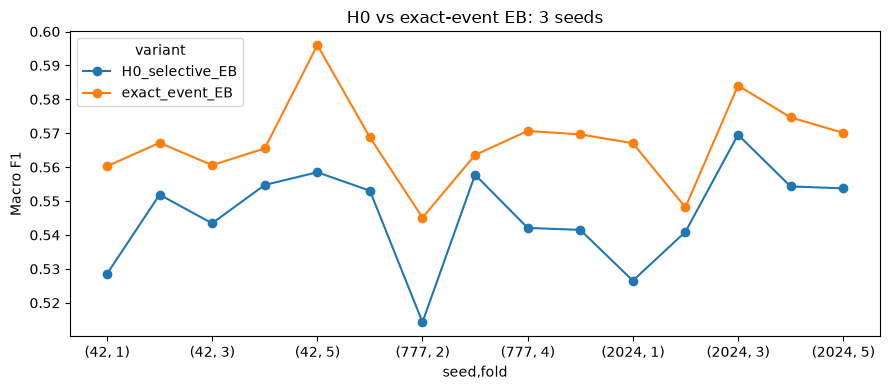

{'seeds': [42, 777, 2024], 'new_feature_or_parameter_search': False, 'all_seed_delta_positive': True, 'mean_delta': 0.02118561843921433, 'minimum_delta': 0.018750308259361304, 'positive_fold_count': 15, 'minimum_class_mean_delta': -0.02173537352435671, 'class_collapse_absent': True, 'leakage_check': True, 'nan_as_mutation_count': 0, 'accepted_3seed': True}


In [3]:
import json
import matplotlib.pyplot as plt
import pandas as pd

seed_summary = pd.read_csv(RESULT / f'{RUN_ID}_3seed_summary.csv')
aggregate = pd.read_csv(RESULT / f'{RUN_ID}_3seed_aggregate.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_3seed_fold_metrics.csv')
decision = json.loads((RESULT / f'{RUN_ID}_3seed_decision.json').read_text())
assert seed_summary.leakage_check.all() and seed_summary.nan_as_mutation_count.eq(0).all()
display(seed_summary.sort_values(['seed', 'variant']))
display(aggregate)
display(folds.pivot(index=['seed', 'fold'], columns='variant', values='macro_f1'))
folds.pivot(index=['seed', 'fold'], columns='variant', values='macro_f1').plot(marker='o', figsize=(9, 4), title='H0 vs exact-event EB: 3 seeds')
plt.ylabel('Macro F1'); plt.tight_layout(); plt.show()
print(decision)